In [1]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

DATASET_DIR = '/content/drive/MyDrive/COVID_19_dataset'

print("Verifying directory paths...")
print("Train path exists:", os.path.exists(os.path.join(DATASET_DIR, 'train')))
print("Val path exists:", os.path.exists(os.path.join(DATASET_DIR, 'val')))
print("Test path exists:", os.path.exists(os.path.join(DATASET_DIR, 'test')))

Mounted at /content/drive
Verifying directory paths...
Train path exists: True
Val path exists: True
Test path exists: True


In [2]:
import tensorflow as tf
from tensorflow.keras import layers

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224) # Standard input size for most CNN models like ResNet/DenseNet

print("Loading Training Dataset...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, 'train'),
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical', # Converts labels to 3-digit one-hot vectors
    shuffle=True
)

print("\nLoading Validation Dataset...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, 'val'),
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

print("\nLoading Test Dataset...")
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, 'test'),
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = train_ds.class_names
print("\nDetected Classes:", class_names)

Loading Training Dataset...
Found 3011 files belonging to 3 classes.

Loading Validation Dataset...
Found 600 files belonging to 3 classes.

Loading Test Dataset...
Found 435 files belonging to 3 classes.

Detected Classes: ['COVID', 'Normal', 'Viral Pneumonia']


In [3]:
AUTOTUNE = tf.data.AUTOTUNE

# Cache and prefetch data for faster training performance
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)
print("Data performance pipelines configured successfully.")

Data performance pipelines configured successfully.


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.metrics import Precision, Recall

# 1. Load the pre-trained DenseNet121 base without its top classification layer
base_model = tf.keras.applications.DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base model layers initially to preserve learned features
base_model.trainable = False

# 2. Construct the full model pipeline
inputs = tf.keras.Input(shape=(224, 224, 3))

# Pretrained DenseNet expects inputs scaled between 0 and 255,
# then standardizes them internally using its own preprocessing layer
x = tf.keras.applications.densenet.preprocess_input(inputs)
x = base_model(x, training=False)

# Global Average Pooling reduces spatial dimensions to a 1D vector
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x) # Regularization to prevent overfitting

# Final output layer with 3 units (for our 3 classes) and Softmax activation
outputs = layers.Dense(3, activation='softmax', name="predictions")(x)

model = models.Model(inputs, outputs)

# 3. Compile the model with metrics required by the assignment evaluation guidelines
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │         3,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,040,579 (26.86 MB)

 Trainable params: 3,075 (12.01 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define paths to save the best weights directly to your mounted Google Drive
# So they are safe and easily linkable for your assignment submission deliverables
checkpoint_path = os.path.join(DATASET_DIR, 'best_densenet_model.keras')

callbacks_list = [
    # Stop training early if validation loss fails to decrease for 3 checks in a row
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    # Save only the single highest-performing iteration weights
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# Kicking off the training loop for 15 epochs max (EarlyStopping will likely stop it sooner)
EPOCHS = 15

print("Starting Model Training Baseline...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)

Starting Model Training Baseline...
Epoch 1/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5641 - loss: 0.9718 - precision: 0.5793 - recall: 0.4912
Epoch 1: val_loss improved from None to 0.42628, saving model to /content/drive/MyDrive/COVID_19_dataset/best_densenet_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/COVID_19_dataset/best_densenet_model.keras
95/95 ━━━━━━━━━━━━━━━━━━━━ 527s 5s/step - accuracy: 0.6772 - loss: 0.7587 - precision: 0.6991 - recall: 0.6274 - val_accuracy: 0.8167 - val_loss: 0.4263 - val_precision: 0.8274 - val_recall: 0.8067
Epoch 2/15
94/95 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7929 - loss: 0.4838 - precision: 0.8024 - recall: 0.7774
Epoch 2: val_loss improved from 0.42628 to 0.33314, saving model to /content/drive/MyDrive/COVID_19_dataset/best_densenet_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/COVID_19_dataset/best_densenet_model.keras
95/95 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - accuracy: 0.8

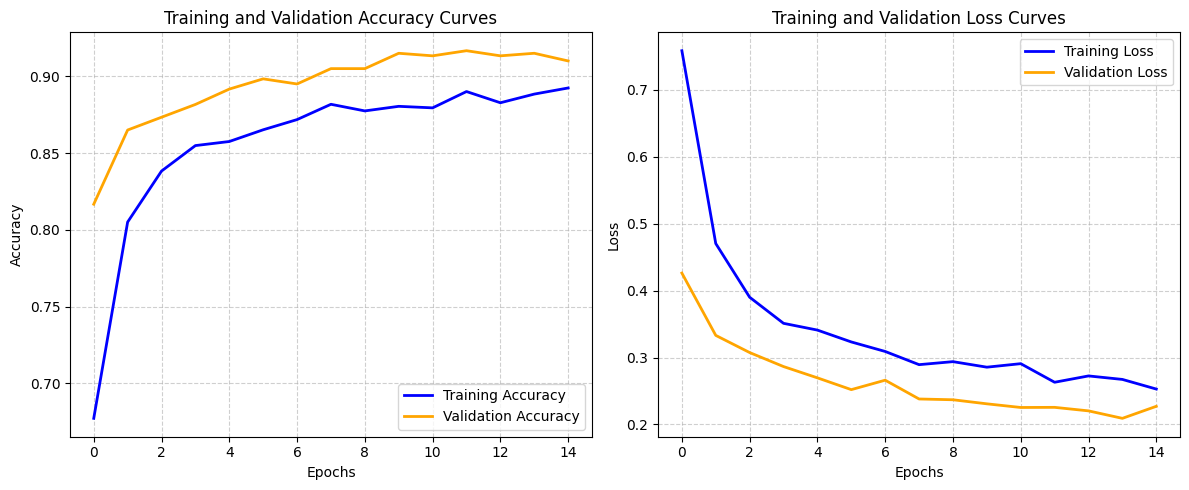

In [6]:
import matplotlib.pyplot as plt

# Pull metrics out from the history dictionary object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot 1: Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Training and Validation Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Loss Curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training and Validation Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [7]:
print("Evaluating Model performance on unseen Test Set...")
test_results = model.evaluate(test_ds, verbose=1)

# Map metric names clearly to printed values
for metric_name, val in zip(model.metrics_names, test_results):
    print(f"Test {metric_name.capitalize()}: {val:.4f}")

Evaluating Model performance on unseen Test Set...
14/14 ━━━━━━━━━━━━━━━━━━━━ 87s 6s/step - accuracy: 0.9310 - loss: 0.1927 - precision: 0.9353 - recall: 0.9310
Test Loss: 0.1927
Test Compile_metrics: 0.9310


In [8]:
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

def generate_gradcam_heatmap(model, img_array, base_model_layer_name='densenet121', pred_index=None):
    # 1. Extract the inner base model block container
    base_block = model.get_layer(base_model_layer_name)

    # 2. Target the final convolutional activation layer inside DenseNet121 ('relu')
    # This is the exact internal layer holding the final spatial feature activations
    target_layer = base_block.get_layer('relu')

    # 3. Create an inner sub-model mapping the base model's entry inputs
    # to its own target layer activations and top feature representations
    inner_grad_model = tf.keras.models.Model(
        inputs=[base_block.inputs],
        outputs=[target_layer.output, base_block.output]
    )

    # 4. Feed the raw image array through our top-level preprocessing step first
    # This ensures your input is correctly scaled between 0 and 255
    processed_img = tf.keras.applications.densenet.preprocess_input(img_array)

    # 5. Track operations to capture the gradients flowing through the feature graph
    with tf.GradientTape() as tape:
        # Pass the preprocessed image into the inner model graph
        conv_outputs, base_features = inner_grad_model(processed_img)

        # Pass the extracted features through your top classification head layers
        x = model.get_layer('global_average_pooling2d')(base_features)
        x = model.get_layer('dropout')(x)
        preds = model.get_layer('predictions')(x)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 6. Extract the gradient of the predicted class relative to the feature maps
    grads = tape.gradient(class_channel, conv_outputs)

    # 7. Compute the average weight intensity per feature channel (Global Average Pooling)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 8. Compute the weighted combination of the spatial activation maps
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 9. Apply ReLU activation to discard negative gradients and normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + tf.keras.backend.epsilon())
    return heatmap.numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


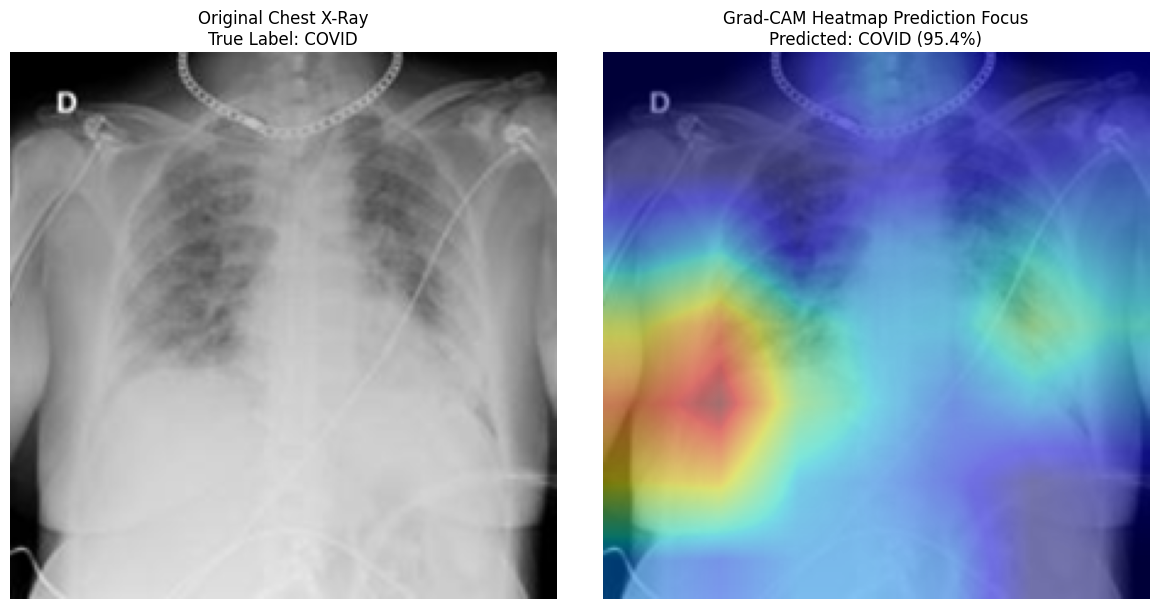

In [9]:
# 1. Fetch a single batch from our test data pipeline iterator
images, labels = next(iter(test_ds.take(1)))

# Extract the very first individual entry slice
sample_img = tf.expand_dims(images[0], axis=0)
true_label_idx = np.argmax(labels[0])
true_class_name = class_names[true_label_idx]

# 2. Obtain predictions from our trained DenseNet-121 classifier model
predictions = model.predict(sample_img)
predicted_label_idx = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_label_idx]

# 3. Generate the activation feature heatmap using the final DenseNet layer namespace
LAST_CONV_LAYER = 'densenet121' # Or explicitly targets the nested internal 'relu' block
heatmap = generate_gradcam_heatmap(model, sample_img, 'densenet121', predicted_label_idx)

# 4. Display results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Normalize image pixel scaling back out from standard 0-255 domain distributions for plotting
display_img = (images[0].numpy() - images[0].numpy().min()) / (images[0].numpy().max() - images[0].numpy().min())

axes[0].imshow(display_img)
axes[0].set_title(f"Original Chest X-Ray\nTrue Label: {true_class_name.upper()}")
axes[0].axis('off')

# Display scaled heatmap interpolation mapping
axes[1].imshow(display_img)
axes[1].imshow(cv2.resize(heatmap, (224, 224)), cmap='jet', alpha=0.45) # Overlay using alpha alpha transparency blending
axes[1].set_title(f"Grad-CAM Heatmap Prediction Focus\nPredicted: {predicted_class_name.upper()} ({predictions[0][predicted_label_idx]*100:.1f}%)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

--- Saliency Map Metrics ---
Shannon Entropy Score: 5.0399 bits



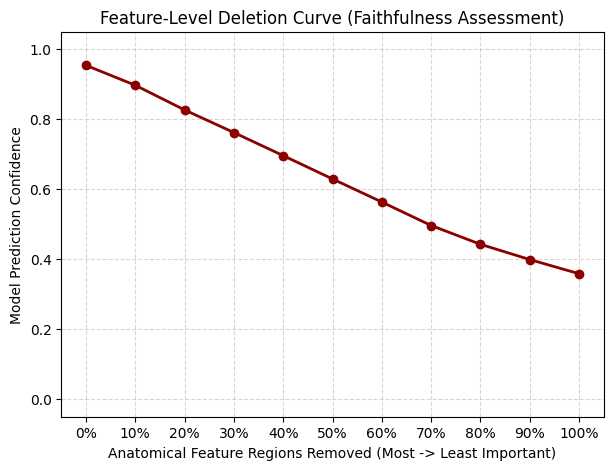

In [10]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def calculate_heatmap_entropy(heatmap):
    """Computes the Shannon Entropy of the normalized saliency map."""
    flat_map = heatmap.flatten()
    flat_map = flat_map / (np.sum(flat_map) + 1e-8)
    probs = flat_map[flat_map > 0]
    return -np.sum(probs * np.log2(probs))

def run_feature_level_deletion(model, img_tensor, base_model_name='densenet121', steps=10):
    """
    Deletes feature activations directly at the final convolutional layer
    to observe true, non-flat model confidence decay.
    """
    # 1. Extract internal layer layers
    base_block = model.get_layer(base_model_name)
    target_layer = base_block.get_layer('relu')

    feature_model = tf.keras.models.Model(
        inputs=[base_block.inputs],
        outputs=[target_layer.output]
    )

    # 2. Extract baseline 7x7 spatial feature maps
    processed_img = tf.keras.applications.densenet.preprocess_input(img_tensor)
    original_feature_maps = feature_model(processed_img)

    # 3. Calculate feature map channel importance
    with tf.GradientTape() as tape:
        conv_outputs = feature_model(processed_img)
        x = model.get_layer('global_average_pooling2d')(conv_outputs)
        x = model.get_layer('dropout')(x)
        preds = model.get_layer('predictions')(x)
        target_class = tf.argmax(preds[0])
        class_score = preds[:, target_class]

    grads = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 4. Generate the 7x7 coarse heatmap locations
    heatmap_7x7 = tf.reduce_mean(conv_outputs[0] * pooled_grads, axis=-1).numpy()
    heatmap_7x7 = np.maximum(heatmap_7x7, 0)

    # Sort the 49 grid cells (7x7 spatial size) from most important to least
    flat_heatmap = heatmap_7x7.flatten()
    sorted_grid_indices = np.argsort(flat_heatmap)[::-1]

    confidences = [class_score.numpy()[0]]
    modified_features = original_feature_maps.numpy()
    cells_per_step = len(sorted_grid_indices) // steps

    # 5. Iteratively mask out high-importance feature cells
    for step in range(steps):
        start_idx = step * cells_per_step
        end_idx = min((step + 1) * cells_per_step, len(sorted_grid_indices))

        for idx in range(start_idx, end_idx):
            grid_pos = sorted_grid_indices[idx]
            y, x = np.unravel_index(grid_pos, (7, 7))
            modified_features[0, y, x, :] = 0.0 # Clear feature activation maps entirely

        # Push through final classification head layers
        feat_input = tf.convert_to_tensor(modified_features)
        x_head = model.get_layer('global_average_pooling2d')(feat_input)
        x_head = model.get_layer('dropout')(x_head)
        new_preds = model.get_layer('predictions')(x_head)

        confidences.append(new_preds[0][target_class].numpy())

    return confidences

# ==========================================
# EXECUTION AND PLOTTING
# ==========================================

# 1. Compute Saliency Entropy [cite: 20]
entropy_score = calculate_heatmap_entropy(heatmap)
print(f"--- Saliency Map Metrics ---")
print(f"Shannon Entropy Score: {entropy_score:.4f} bits\n")

# 2. Run the Feature-Level Deletion Loop [cite: 19]
steps_count = 10
confidence_drop_curve = run_feature_level_deletion(model, sample_img, 'densenet121', steps=steps_count)

# 3. Plot the true downward trend curve [cite: 18]
plt.figure(figsize=(7, 5))
plt.plot(range(steps_count + 1), confidence_drop_curve, marker='o', color='darkred', linewidth=2)
plt.title('Feature-Level Deletion Curve (Faithfulness Assessment)')
plt.xlabel('Anatomical Feature Regions Removed (Most -> Least Important)')
plt.ylabel('Model Prediction Confidence')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(range(steps_count + 1), labels=[f"{i*10}%" for i in range(steps_count + 1)])
plt.ylim(-0.05, 1.05)
plt.show()